In [2]:
# Instalar dependencias si es necesario
# !pip install optuna mlflow scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.sklearn

In [3]:
X_train, X_test, y_train, y_test = joblib.load('PKL_datos/splits_prep.pkl')

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (3004, 54)
X_test:  (751, 54)
y_train: (3004,)
y_test:  (751,)


In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred_log = model.predict(X_test)
    
    # Métricas en escala log
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2_log   = r2_score(y_test, y_pred_log)
    
    # Métricas en escala original (USD)
    y_pred_usd = np.expm1(y_pred_log)
    y_test_usd = np.expm1(y_test)
    rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
    mae_usd  = mean_absolute_error(y_test_usd, y_pred_usd)
    r2_usd   = r2_score(y_test_usd, y_pred_usd)
    
    return {
        'rmse_log': rmse_log,
        'r2_log':   r2_log,
        'rmse_usd': rmse_usd,
        'mae_usd':  mae_usd,
        'r2_usd':   r2_usd
    }

In [ ]:
import os
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('ds_salaries_regression')

✅ MLflow configurado


### Regresion Lineal

In [6]:
with mlflow.start_run(run_name='LinearRegression_baseline'):
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    
    metrics_lr = evaluate_model(model_lr, X_test, y_test)
    
    # Log en MLflow
    mlflow.log_params({'model': 'LinearRegression', 'fit_intercept': True})
    mlflow.log_metrics(metrics_lr)
    mlflow.sklearn.log_model(model_lr, 'model')

print('Linear Regression:')
for k, v in metrics_lr.items():
    print(f'  {k}: {v:.4f}')

2026/06/08 07:11:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 07:11:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression:
  rmse_log: 0.4064
  r2_log: 0.5390
  rmse_usd: 49255.6532
  mae_usd: 36455.9669
  r2_usd: 0.3854


### Modelo 2 — Ridge Regression + Optuna

In [7]:
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

study_ridge = optuna.create_study(direction='minimize', study_name='ridge')
study_ridge.optimize(objective_ridge, n_trials=50, show_progress_bar=True)

best_alpha = study_ridge.best_params['alpha']
print(f'\nMejor alpha: {best_alpha:.4f}')

with mlflow.start_run(run_name='Ridge_optuna'):
    model_ridge = Ridge(alpha=best_alpha)
    model_ridge.fit(X_train, y_train)
    metrics_ridge = evaluate_model(model_ridge, X_test, y_test)
    
    mlflow.log_params({**study_ridge.best_params, 'model': 'Ridge', 'n_trials': 50})
    mlflow.log_metrics(metrics_ridge)
    mlflow.sklearn.log_model(model_ridge, 'model')

print('Ridge Regression:')
for k, v in metrics_ridge.items():
    print(f'  {k}: {v:.4f}')

Best trial: 12. Best value: 0.40435: 100%|██████████| 50/50 [00:00<00:00, 117.52it/s]
2026/06/08 07:12:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 07:12:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Mejor alpha: 5.9695
Ridge Regression:
  rmse_log: 0.4043
  r2_log: 0.5436
  rmse_usd: 49255.3282
  mae_usd: 36342.6755
  r2_usd: 0.3855


### Modelo 3 — Decision Tree + Optuna

In [8]:
def objective_dt(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 2, 20),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

study_dt = optuna.create_study(direction='minimize', study_name='decision_tree')
study_dt.optimize(objective_dt, n_trials=50, show_progress_bar=True)

print(f'\nMejores params: {study_dt.best_params}')

with mlflow.start_run(run_name='DecisionTree_optuna'):
    model_dt = DecisionTreeRegressor(**study_dt.best_params, random_state=42)
    model_dt.fit(X_train, y_train)
    metrics_dt = evaluate_model(model_dt, X_test, y_test)
    
    mlflow.log_params({**study_dt.best_params, 'model': 'DecisionTree', 'n_trials': 50})
    mlflow.log_metrics(metrics_dt)
    mlflow.sklearn.log_model(model_dt, 'model')

print('Decision Tree:')
for k, v in metrics_dt.items():
    print(f'  {k}: {v:.4f}')

Best trial: 35. Best value: 0.408421: 100%|██████████| 50/50 [00:00<00:00, 69.01it/s] 
2026/06/08 07:12:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 07:12:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Mejores params: {'max_depth': 18, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': None}
Decision Tree:
  rmse_log: 0.4084
  r2_log: 0.5344
  rmse_usd: 49559.8702
  mae_usd: 36086.0028
  r2_usd: 0.3778


### Modelo 4 — Gradient Boosting + Optuna

In [9]:
def objective_gb(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 300),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':       trial.suggest_int('max_depth', 2, 8),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

study_gb = optuna.create_study(direction='minimize', study_name='gradient_boosting')
study_gb.optimize(objective_gb, n_trials=50, show_progress_bar=True)

print(f'\nMejores params: {study_gb.best_params}')

with mlflow.start_run(run_name='GradientBoosting_optuna'):
    model_gb = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
    model_gb.fit(X_train, y_train)
    metrics_gb = evaluate_model(model_gb, X_test, y_test)
    
    mlflow.log_params({**study_gb.best_params, 'model': 'GradientBoosting', 'n_trials': 50})
    mlflow.log_metrics(metrics_gb)
    mlflow.sklearn.log_model(model_gb, 'model')

print('Gradient Boosting:')
for k, v in metrics_gb.items():
    print(f'  {k}: {v:.4f}')

Best trial: 39. Best value: 0.396621: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]



Mejores params: {'n_estimators': 281, 'learning_rate': 0.02142473451750988, 'max_depth': 7, 'min_samples_leaf': 1, 'subsample': 0.9129977959507493}


2026/06/08 07:12:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 07:12:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting:
  rmse_log: 0.3966
  r2_log: 0.5609
  rmse_usd: 49065.8210
  mae_usd: 36062.7985
  r2_usd: 0.3902


### Modelo 5 — Random Forest + Optuna

In [10]:
def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 20),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

study_rf = optuna.create_study(direction='minimize', study_name='random_forest')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print(f'\nMejores params: {study_rf.best_params}')

with mlflow.start_run(run_name='RandomForest_optuna'):
    model_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
    model_rf.fit(X_train, y_train)
    metrics_rf = evaluate_model(model_rf, X_test, y_test)
    
    mlflow.log_params({**study_rf.best_params, 'model': 'RandomForest', 'n_trials': 50})
    mlflow.log_metrics(metrics_rf)
    mlflow.sklearn.log_model(model_rf, 'model')

print('Random Forest:')
for k, v in metrics_rf.items():
    print(f'  {k}: {v:.4f}')

Best trial: 33. Best value: 0.39823: 100%|██████████| 50/50 [00:25<00:00,  1.95it/s] 



Mejores params: {'n_estimators': 231, 'max_depth': 16, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


2026/06/08 07:13:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 07:13:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest:
  rmse_log: 0.3982
  r2_log: 0.5573
  rmse_usd: 49033.9151
  mae_usd: 36169.2391
  r2_usd: 0.3910


In [11]:
results = pd.DataFrame({
    'Linear Regression': metrics_lr,
    'Ridge':             metrics_ridge,
    'Decision Tree':     metrics_dt,
    'Gradient Boosting': metrics_gb,
    'Random Forest':     metrics_rf,
}).T.round(4)

results = results.sort_values('r2_usd', ascending=False)
print('COMPARACIÓN DE MODELOS (ordenado por R² en USD)')
print(results.to_string())

COMPARACIÓN DE MODELOS (ordenado por R² en USD)
                   rmse_log  r2_log    rmse_usd     mae_usd  r2_usd
Random Forest        0.3982  0.5573  49033.9151  36169.2391  0.3910
Gradient Boosting    0.3966  0.5609  49065.8210  36062.7985  0.3902
Ridge                0.4043  0.5436  49255.3282  36342.6755  0.3855
Linear Regression    0.4064  0.5390  49255.6532  36455.9669  0.3854
Decision Tree        0.4084  0.5344  49559.8702  36086.0028  0.3778


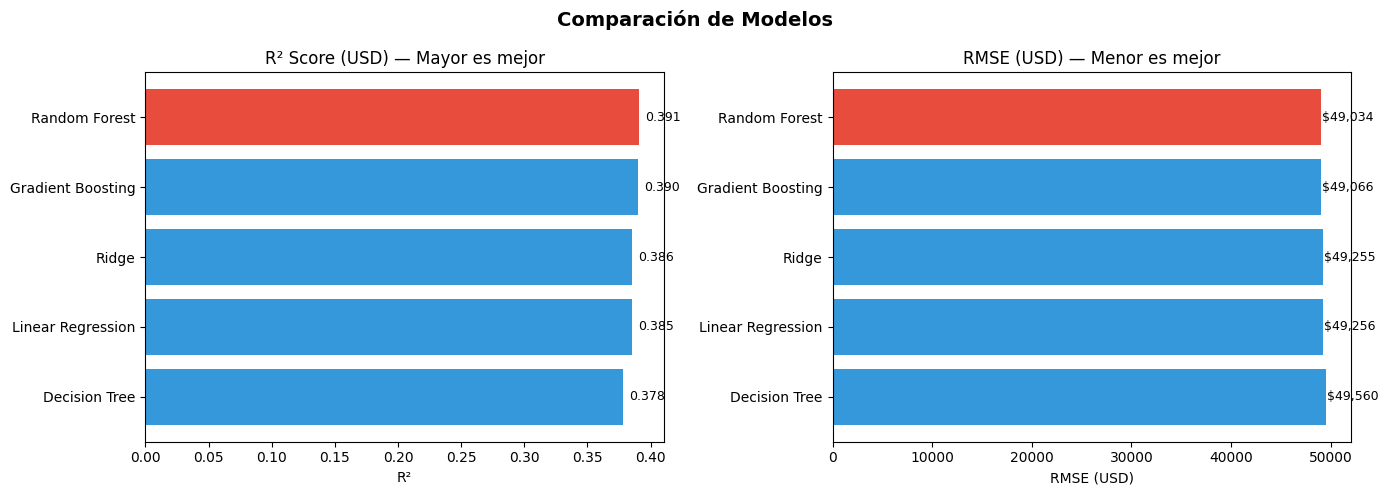

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_names = results.index.tolist()
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(models_names))]

# R²
axes[0].barh(models_names[::-1], results['r2_usd'].values[::-1], color=colors[::-1])
axes[0].set_title('R² Score (USD) — Mayor es mejor')
axes[0].set_xlabel('R²')
axes[0].axvline(x=0, color='black', linewidth=0.5)
for i, v in enumerate(results['r2_usd'].values[::-1]):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# RMSE USD
axes[1].barh(models_names[::-1], results['rmse_usd'].values[::-1], color=colors[::-1])
axes[1].set_title('RMSE (USD) — Menor es mejor')
axes[1].set_xlabel('RMSE (USD)')
for i, v in enumerate(results['rmse_usd'].values[::-1]):
    axes[1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)

plt.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Mejor modelo: Random Forest


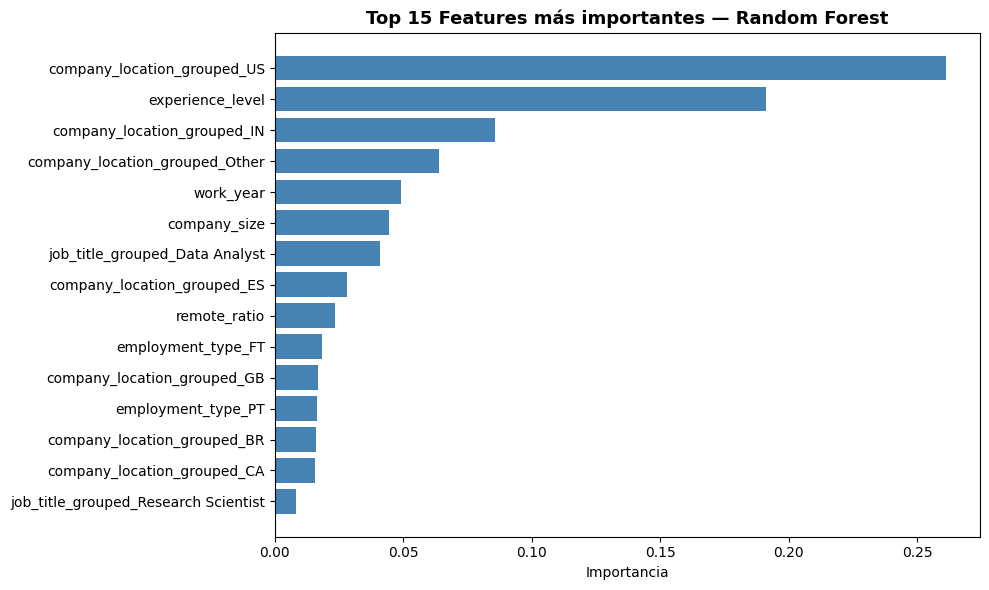

In [ ]:
# Usar el mejor modelo
best_name = results.index[0]
model_map = {
    'Linear Regression': model_lr,
    'Ridge': model_ridge,
    'Decision Tree': model_dt,
    'Gradient Boosting': model_gb,
    'Random Forest': model_rf,
}
best_model = model_map[best_name]
print(f'Mejor modelo: {best_name}')

# Feature importance (solo para modelos basados en árboles)
if hasattr(best_model, 'feature_importances_'):
    preprocessor = joblib.load('PKL_datos/preprocessor.pkl')
    
    # Obtener nombres de features del ColumnTransformer
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if hasattr(transformer, 'get_feature_names_out'):
            feature_names.extend(transformer.get_feature_names_out(cols).tolist())
        else:
            feature_names.extend(cols if isinstance(cols, list) else [cols])
    
    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_features.index[::-1], top_features.values[::-1], color='steelblue')
    plt.title(f'Top 15 Features más importantes — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'El modelo {best_name} no tiene feature_importances_. Usa el gráfico de coeficientes.')

In [18]:
joblib.dump(best_model, 'PKL_Modelo/best_model.pkl')
joblib.dump(results, 'PKL_Modelo/model_results.pkl')

print(f'Mejor modelo guardado: {best_name}')
print(f'R²  (USD): {results.loc[best_name, "r2_usd"]:.4f}')
print(f'RMSE(USD): ${results.loc[best_name, "rmse_usd"]:,.0f}')
print(f'MAE (USD): ${results.loc[best_name, "mae_usd"]:,.0f}')

Mejor modelo guardado: Random Forest
R²  (USD): 0.3910
RMSE(USD): $49,034
MAE (USD): $36,169
